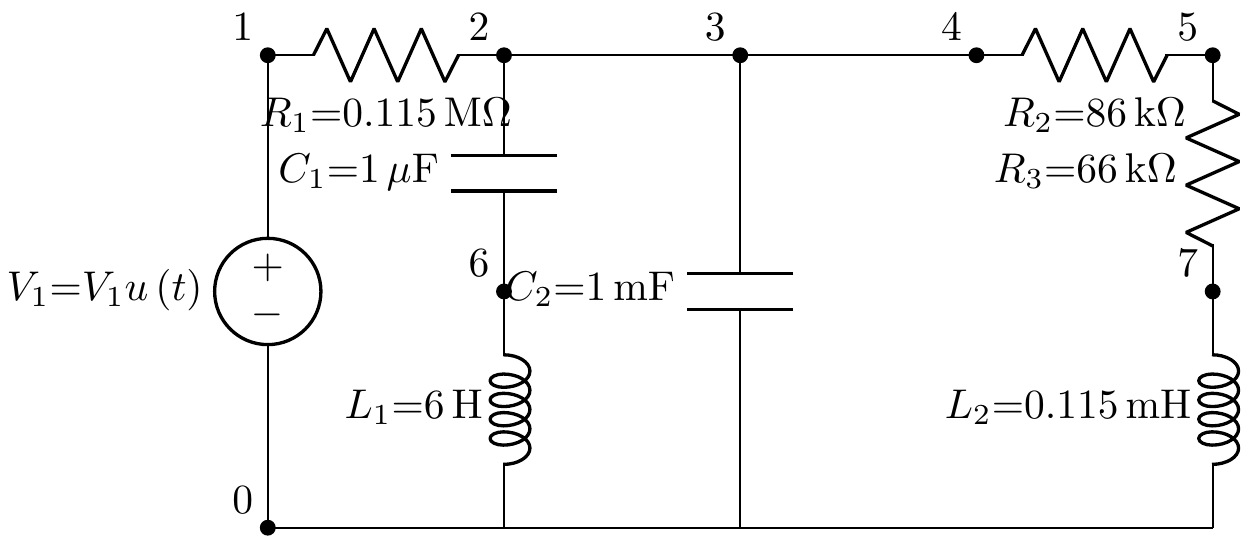

the voltage of R1 is SuperpositionVoltage({s: V1/s - V1*(69*s**3 + 91200000000*s**2 + 11500000*s + 15200000000000000)/7935/(s**5 + 152000000001*s**4/115 + 32304764500*s**3/1587 + 15215200000100000*s**2/69 + 1780000000000000*s/529)})
R2 voltage is SuperpositionVoltage({s: (V1*(69*s**3 + 39600000000*s**2 + 11500000*s + 6600000000000000)/7935)/(s**5 + 152000000001*s**4/115 + 32304764500*s**3/1587 + 15215200000100000*s**2/69 + 1780000000000000*s/529) - V1*(69*s**3 + 91200000000*s**2 + 11500000*s + 15200000000000000)/7935/(s**5 + 152000000001*s**4/115 + 32304764500*s**3/1587 + 15215200000100000*s**2/69 + 1780000000000000*s/529)})
R3 voltage is SuperpositionVoltage({s: -V1*(3*s**2 + 500000)/345/(s**4 + 152000000001*s**3/115 + 32304764500*s**2/1587 + 15215200000100000*s/69 + 1780000000000000/529) + (V1*(69*s**3 + 39600000000*s**2 + 11500000*s + 6600000000000000)/7935)/(s**5 + 152000000001*s**4/115 + 32304764500*s**3/1587 + 15215200000100000*s**2/69 + 1780000000000000*s/529)})


In [25]:
from lcapy import *

c = Circuit("""

V1 1 0 step; down
R1 1 2 115k; right


C1 2 6 1u; down
L1 6 0_6 6; down
W 0 0_6; right


W 2 3; right
C2 3 0_3 1m; down

W 0_6 0_3; right


W 3 4; right
R2 4 5 86k; right

R3 5 7 66k; down
L2 7 0_7 0.115m; down
W 0_3 0_7; right

""")

c.draw()

V_R1 = c[1].V - c[2].V
print("the voltage of R1 is" ,V_R1)
V_R2 = c[5].V - c[4].V
V_R3 =  c[5].V - c[7].V
print("R2 voltage is" ,V_R2)
print("R3 voltage is" ,V_R3)

HR3 = c.transfer(5, 7, 1, 0)
print("R3 transfer function is",HR3)
#HC1 = c.transfer(2, 6, 1, 0)
#print("C1 transfer function is",HC1)


 # R3 analysis

In [26]:
import numpy as np
from sympy import symbols, lambdify

VR3 = c[5].V - c[7].V
VR3_s = VR3.expr['s'] # Stripping the s domain part from Lcapy's superposition object

s_sym, V1_sym = symbols('s V1') # Creating SymPy symbols

# turn symbolic expression into a function compatible with numpy
f = lambdify((s_sym, V1_sym), VR3_s, 'numpy')

w = 1000

# For sinusoidal steady-state analysis, substitute: s = jω
# s = jω
# amplitude 10 V
Hc = f(1j*w, 10)

mag = abs(Hc)
phase_deg = np.angle(Hc, deg=True)

print("V_R3(jw) =", Hc)
print("|V_R3| =", mag, "V")
print("phase =", phase_deg, "deg")

V_R3(jw) = (-3.7764990060740314e-08-5.483882955652926e-13j)
|V_R3| = 3.7764990064721904e-08 V
phase = -179.99916800362408 deg


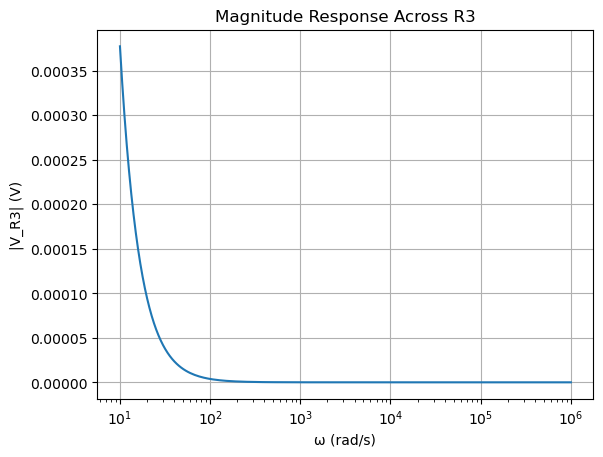

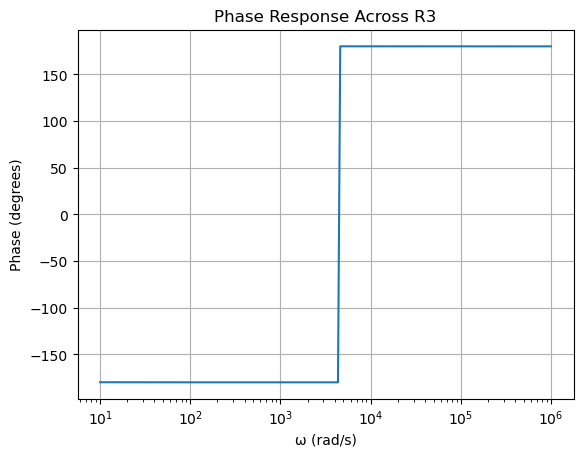

In [29]:
import numpy as np
from sympy import symbols, lambdify


VR3 = c[5].V - c[7].V
VR3_s = VR3.expr['s']
s_sym, V1_sym = symbols('s V1')
f = lambdify((s_sym, V1_sym), VR3_s, 'numpy')
Vin_amp = 10
w_vals = np.logspace(1, 6, 200)  # 10 → 1e6 rad/s omega sweep


V_vals = []        # complex phasor V_R3(jw)
mag_vals = []      # |V|
phase_vals = []    # angle in degrees

# Sweep loop
for w in w_vals:
    Vjw = f(1j*w, Vin_amp))
    V_vals.append(Vjw)
    mag_vals.append(abs(Vjw))
    phase_vals.append(np.angle(Vjw, deg=True))


plt.figure()
plt.semilogx(w_vals, mag_vals)
plt.xlabel('ω (rad/s)')
plt.ylabel('|V_R3| (V)')
plt.title('Magnitude Response Across R3')
plt.grid()
plt.figure()
plt.semilogx(w_vals, phase_vals)
plt.xlabel('ω (rad/s)')
plt.ylabel('Phase (degrees)')
plt.title('Phase Response Across R3')
plt.grid()

plt.show()